# Euclid NISP Y-Band Self-Calibration & Mosaic Pipeline
Runs the full self-calibration and mosaicking pipeline on pre-existing reprojected Euclid NISP Y-band frames (Euclid Deep Field North).

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import sys
import time
import shutil
import gc
import glob as glob_module
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from tqdm import tqdm

parent_path = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
sys.path.insert(0, parent_path)

from SelfCal import PipelineWrapper
from SelfCal.MakeMap import set_hdd_io_limit, compute_x0_from_Ab
from SelfCal.MapHelper import compute_chunk_adjacency, mean_preserving_spline_2d
from SelfCal.SPHERExUtility import fill_invalid_offsets
from threadpoolctl import threadpool_limits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

HDD_IO_LIMIT = 20
set_hdd_io_limit(HDD_IO_LIMIT)

## Settings

In [2]:
DET_SHAPE = (2040, 2040)
N_CHUNKS_PER_SIDE = 10
CACHE_DIR = '/home/thomasli/spherex/selfcal/cache/'

selfcal_config = PipelineWrapper.PipelineConfig(
    output_dir='/mnt/md124/thomasli/selfcal/outputs/',
    run_name='EDFN_Y_6p0arcsec',
    resolution_arcsec=6.0,
)

# Euclid NISP DQ bits 11 and 15 are set on ~100% and ~84% of pixels respectively;
# they must be ignored or nearly all data is masked out
EUCLID_DQ_IGNORE = [11, 15]

calibration_kwargs = {
    'apply_mask': True,
    'apply_weight': False,
    'outlier_thresh': 5.0,
    'ignore_list': EUCLID_DQ_IGNORE,
    'batch_size': 20,
    'offset_regularization': True,
    'reg_weight': 0.1,
    'weighted_damping': False,
    'damp_weight': 0.1,
    'max_workers': 16,
    'postprocess_func': None,
}

lsqr_kwargs = {
    'atol': 1e-6,
    'btol': 1e-6,
    'damp': 0,
    'iter_lim': 200,
    'precondition': True,
    'solver': 'lsqr',
}

mosaic_kwargs = {
    'apply_mask': True,
    'apply_weight': False,
    'make_std_map': True,
    'apply_sigma_clipping': True,
    'sigma': 2.0,
    'ignore_list': EUCLID_DQ_IGNORE,
    'cache_batch_size': 20,
    'coadd_batch_size': 30,
    'cache_intermediate': True,
    'max_workers': 32,
}

mosaic_oversample_factor = 1

cal_file = 'cal_EDFN_Y.h5'
mos_file = 'mosaic_EDFN_Y.fits'
cache_dir = os.path.join(CACHE_DIR, 'cache_EDFN_Y')

## Copy Reproj Files to NVMe

In [3]:
nvme_reproj_dir = os.path.join(CACHE_DIR, f'reproj_nvme_{selfcal_config.run_name}')
os.makedirs(nvme_reproj_dir, exist_ok=True)

hdd_reproj_files = sorted(glob_module.glob(os.path.join(selfcal_config.reproj_dir, '*.h5')))

def copy_to_nvme(src_path):
    dst_path = os.path.join(nvme_reproj_dir, os.path.basename(src_path))
    if not os.path.exists(dst_path):
        shutil.copy2(src_path, dst_path)
    return dst_path

print(f"Copying {len(hdd_reproj_files)} reproj files to NVMe ({nvme_reproj_dir})...")
t_copy = time.time()
with ThreadPoolExecutor(max_workers=HDD_IO_LIMIT or 20) as executor:
    for _ in tqdm(executor.map(copy_to_nvme, hdd_reproj_files),
                  total=len(hdd_reproj_files), desc="HDD->NVMe", unit="file"):
        pass
print(f"Reproj file copy complete in {time.time() - t_copy:.2f} seconds.")

# NVMe can handle massively parallel reads — disable the HDD I/O throttle
set_hdd_io_limit(None)

def remap_to_nvme(file_list):
    """Replace directory prefix with nvme_reproj_dir, keeping filenames."""
    return [os.path.join(nvme_reproj_dir, os.path.basename(f)) for f in file_list]

Copying 14464 reproj files to NVMe (/home/thomasli/spherex/selfcal/cache/reproj_nvme_EDFN_Y_6p0arcsec)...


HDD->NVMe:   0%|                                                                                                        | 0/14464 [00:00<?, ?file/s]

HDD->NVMe: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 14464/14464 [00:00<00:00, 49459.41file/s]

Reproj file copy complete in 0.50 seconds.


## Chunk Map & Adjacency

In [4]:
def compute_chunk_edges(det_shape, chunk_size):
    '''Split detector into chunks and return edge of chunks'''
    det_h, det_w = det_shape
    chunk_h, chunk_w = chunk_size
    y_edges = np.arange(0, det_h + 1, chunk_h)
    x_edges = np.arange(0, det_w + 1, chunk_w)
    return x_edges, y_edges

def make_chunk_map(det_shape, chunk_size):
    '''Make a chunk map for the detector'''
    x_edges, y_edges = compute_chunk_edges(det_shape, chunk_size)
    chunk_map = np.zeros(det_shape, dtype=int)
    chunk_id = 0
    for j in range(len(y_edges)-1):
        y_low = y_edges[j]
        y_high = y_edges[j+1]
        for i in range(len(x_edges)-1):
            x_low = x_edges[i]
            x_high = x_edges[i+1]
            chunk_map[y_low:y_high, x_low:x_high] = chunk_id
            chunk_id += 1
    return chunk_map

def make_square_chunk_map(n_chunks_per_side, det_shape=(2040, 2040)):
    '''Make a square chunk map for the detector'''
    det_h, det_w = det_shape
    chunk_h = det_h // n_chunks_per_side
    chunk_w = det_w // n_chunks_per_side
    return make_chunk_map(det_shape, (chunk_h, chunk_w))

chunk_map = make_square_chunk_map(n_chunks_per_side=N_CHUNKS_PER_SIDE, det_shape=DET_SHAPE)
adj_info = compute_chunk_adjacency(chunk_map, reg_axis='both')

def make_grid_offset_map(chunk_map, chunk_offset, n_side=N_CHUNKS_PER_SIDE, det_shape=DET_SHAPE):
    """Smooth offset interpolation for a regular grid of chunks via mean-preserving spline."""
    offset_grid = chunk_offset.reshape(n_side, n_side).copy()
    offset_grid = fill_invalid_offsets(offset_grid)
    y_edges = np.linspace(0, det_shape[0], n_side + 1)
    x_edges = np.linspace(0, det_shape[1], n_side + 1)
    spl = mean_preserving_spline_2d(y_edges, x_edges, offset_grid)
    h, w = chunk_map.shape
    oversample = h // det_shape[0]
    shift = 0.5 / oversample
    inc = 1.0 / oversample
    y_mesh, x_mesh = np.meshgrid(
        np.arange(shift, det_shape[0] + shift, inc),
        np.arange(shift, det_shape[1] + shift, inc), indexing='ij')
    return spl(y_mesh, x_mesh)

Pre-computing adjacency matrix (Axis: both)...


## Calibration

## Resume Calibration (Optional)
Set `RESUME_FROM_PREVIOUS = True` to continue LSQR from a previous calibration result for additional iterations. Skip this cell otherwise.

In [6]:
os.remove(cal_path)

In [ ]:
t0 = time.time()

cc = PipelineWrapper.Calibrator(selfcal_config, reproj_dir=nvme_reproj_dir)

det_groups = np.array(cc.det_idx_list)

cal_path = os.path.join(selfcal_config.cal_dir, cal_file)
if os.path.exists(cal_path):
    print(f"Calibration file {cal_path} already exists. Skipping calibration.")
else:
    cc.setup_lsqr(
        chunk_map=chunk_map,
        grid_valid_weight=np.ones(DET_SHAPE),
        oversample_factor=1,
        adj_info=adj_info,
        det_groups=det_groups,
        **calibration_kwargs
    )
    print(f"  setup_lsqr: {time.time() - t0:.2f}s")
    print(f"  A shape: {cc.A.shape}, nnz: {cc.A.nnz}")
    print(f"  b shape: {cc.b.shape}")

    t1 = time.time()
    x0 = compute_x0_from_Ab(cc.A, cc.b, cc.ref_shape, cc.num_offset_groups)
    print(f"  Initial guess: {time.time() - t1:.2f}s, x0 shape: {x0.shape}")

    t1 = time.time()
    with threadpool_limits(limits=8, user_api='blas'):
        cc.apply_lsqr(x0=x0, **lsqr_kwargs)
    print(f"  apply_lsqr: {time.time() - t1:.2f}s")

    # Save with original HDD paths so cal file remains valid after NVMe cleanup
    nvme_list = cc.reproj_list
    cc.reproj_list = [os.path.join(selfcal_config.reproj_dir, os.path.basename(f)) for f in nvme_list]
    cal_path = cc.save_calibration(cal_file=cal_file)
    cc.reproj_list = nvme_list

print(f"Calibration total: {time.time() - t0:.2f}s")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 14464/14464 [00:00<00:00, 631133.16it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/ref.fits
Locking detector offsets: 14464 frames -> 14 groups + 14464 frame scalars
Processing 14464 items in 724 batches...



Building A, b matrix: 100%|███████████████████████████████████████████████████████████████████████████████████████| 724/724 [00:34<00:00, 20.80it/s]


Setup LSQR finished in 38.41 seconds.
  setup_lsqr: 38.48s
  A shape: (112567676, 15818302), nnz: 336072958
  b shape: (112567676,)
  Initial guess: 3.99s, x0 shape: (15818302,)
Eliminating 5794832 zero columns (10023470/15818302 active)...
Applying column-norm preconditioning...
Solving least squares for 10023470 unknowns with 112567676 equations (solver=lsqr).
Building parallel SpMV operator (32 threads)...
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 112567676 rows and 10023470 columns
damp = 0.00000000000000e+00   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      200
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   7.052e+05  7.052e+05    1.0e+00  2.4e-06
     1 -2.30917e+01   7.075e+04  7.075e+04    1.0e-01  2.3e-01   1.7e+00  1.0e+00
     2 -2.55884e+01   6.489e+04  6.489e+04    9.2e-02  5.0e-02   2.0e+00  2.3e+00
     3 -2.58397e+01   

In [6]:
# RESUME_FROM_PREVIOUS = True
# RESUME_ITER_LIM = 200

# if RESUME_FROM_PREVIOUS:
#     t0 = time.time()

#     cc = PipelineWrapper.Calibrator(selfcal_config, reproj_dir=nvme_reproj_dir)
#     cc.load_calibration(cal_path=os.path.join(selfcal_config.cal_dir, cal_file))

#     cc.setup_lsqr(
#         chunk_map=chunk_map,
#         grid_valid_weight=np.ones(DET_SHAPE),
#         oversample_factor=1,
#         adj_info=adj_info,
#         mean_offsets=np.zeros(len(cc.reproj_list)),
#         **calibration_kwargs
#     )
#     print(f"  setup_lsqr: {time.time() - t0:.2f}s")

#     t1 = time.time()
#     with threadpool_limits(limits=8, user_api='blas'):
#         cc.apply_lsqr(**{**lsqr_kwargs, 'iter_lim': RESUME_ITER_LIM}, resume=True)
#     print(f"  apply_lsqr (resume): {time.time() - t1:.2f}s")

#     # Save with original HDD paths so cal file remains valid after NVMe cleanup
#     nvme_list = cc.reproj_list
#     cc.reproj_list = [os.path.join(selfcal_config.reproj_dir, os.path.basename(f)) for f in nvme_list]
#     cal_path = cc.save_calibration(cal_file=cal_file)
#     cc.reproj_list = nvme_list

#     print(f"Resume total: {time.time() - t0:.2f}s")

## Calibration Results

In [7]:
skymap = cc.get_skymap()
np.percentile(skymap[np.nonzero(skymap)], [1, 25, 50, 75, 99])

NameError: name 'cc' is not defined

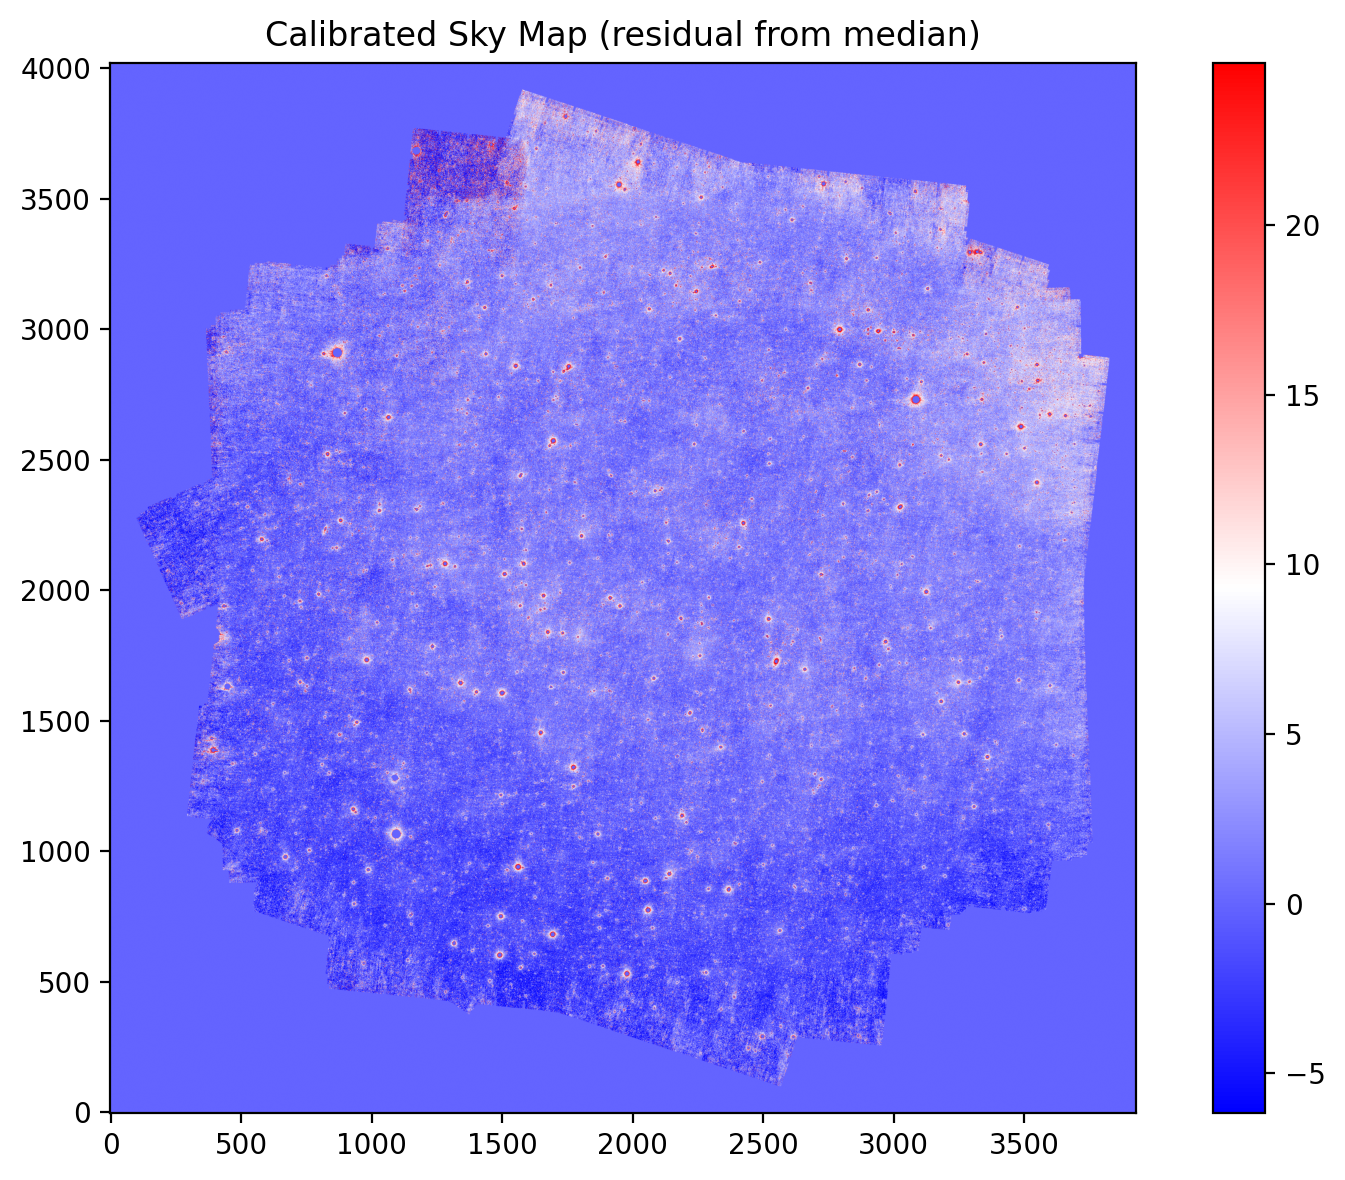

In [10]:
skymap = cc.get_skymap()
low, med, high = np.percentile(skymap[np.nonzero(skymap)], [1, 50, 99])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(skymap, vmin=low, vmax=high, origin='lower', cmap='bwr')
ax.set_title('Calibrated Sky Map (residual from median)')
plt.colorbar(im, ax=ax)
plt.tight_layout()

Offset shape: (14464, 25)
Offset stats:  mean=66.7211  std=4.9920  min=48.4272  max=122.0871
Per-frame mean offset:  mean=66.7211  std=4.8391
Per-frame offset range: mean=4.4944  max=42.7716


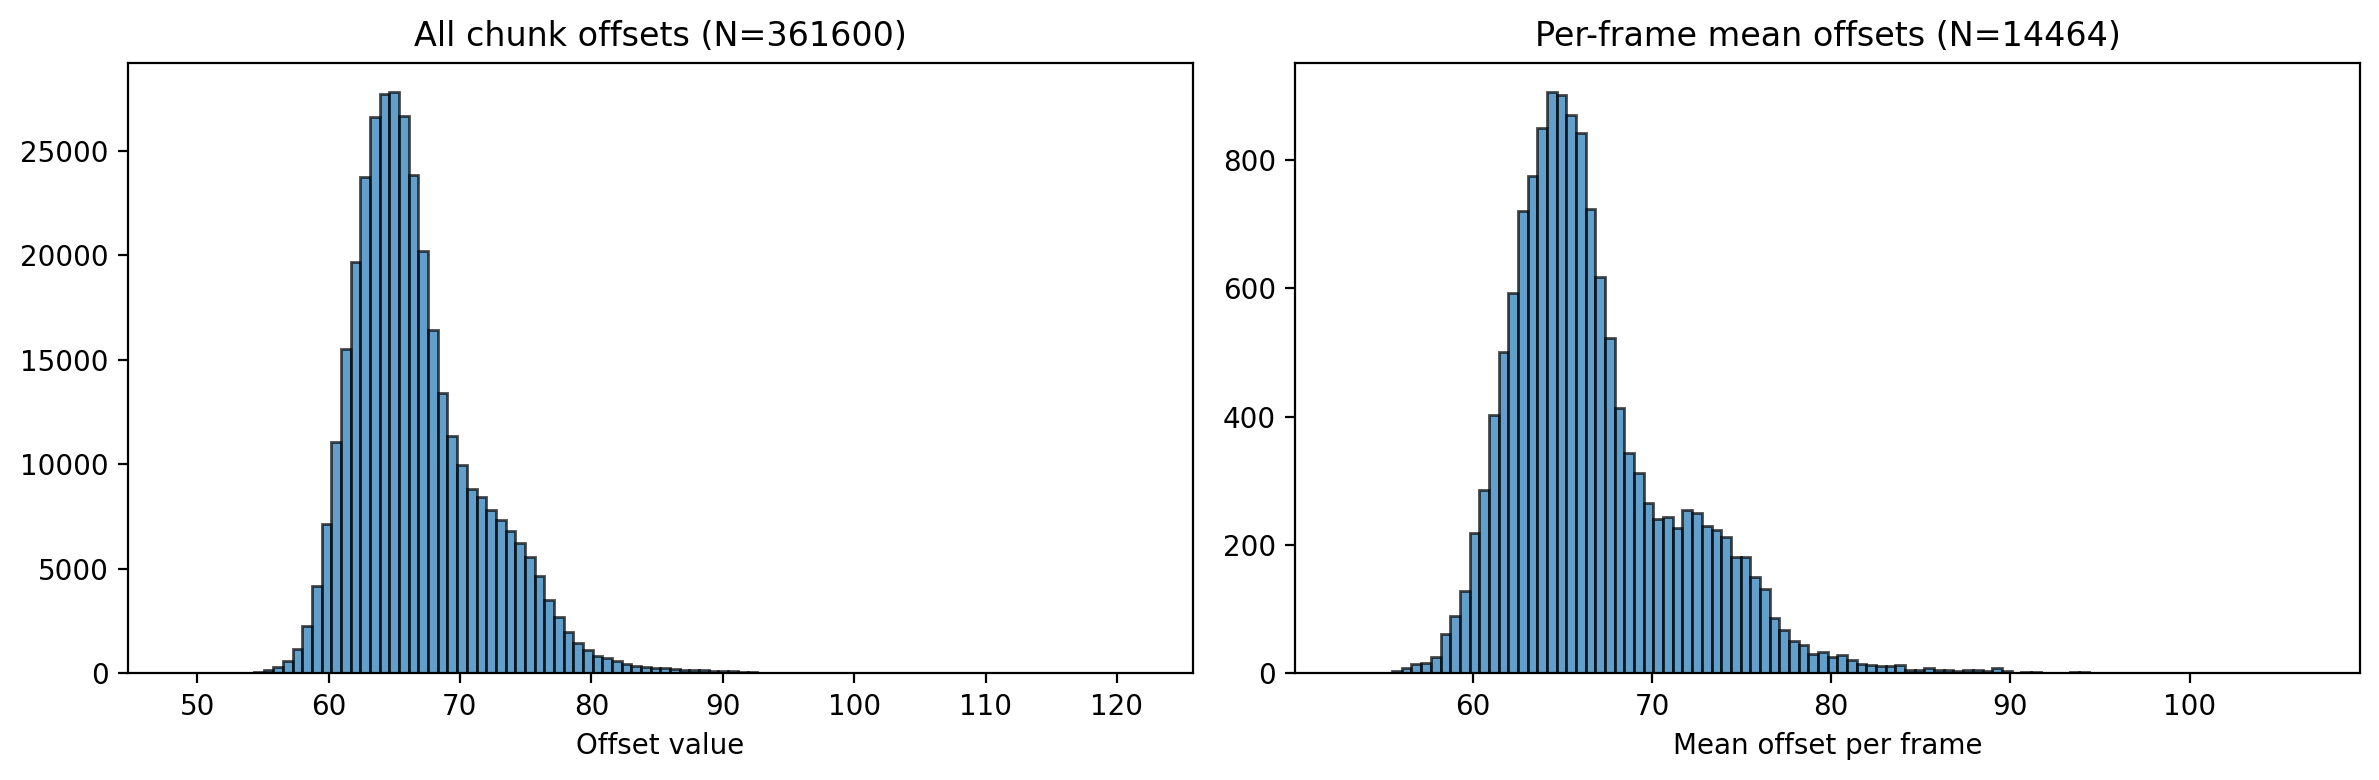

In [63]:
# Offset diagnostics — check that calibration produced meaningful offsets
offset = cc.get_offset()  # shape (num_frames, num_chunks)
print(f"Offset shape: {offset.shape}")
print(f"Offset stats:  mean={offset.mean():.4f}  std={offset.std():.4f}  "
      f"min={offset.min():.4f}  max={offset.max():.4f}")
print(f"Per-frame mean offset:  mean={offset.mean(axis=1).mean():.4f}  "
      f"std={offset.mean(axis=1).std():.4f}")
print(f"Per-frame offset range: mean={np.ptp(offset, axis=1).mean():.4f}  "
      f"max={np.ptp(offset, axis=1).max():.4f}")

# Show offset distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(offset.flatten(), bins=100, edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Offset value')
axes[0].set_title(f'All chunk offsets (N={offset.size})')
axes[1].hist(offset.mean(axis=1), bins=100, edgecolor='k', alpha=0.7)
axes[1].set_xlabel('Mean offset per frame')
axes[1].set_title(f'Per-frame mean offsets (N={offset.shape[0]})')
plt.tight_layout()

## Mosaicking

In [8]:
t0 = time.time()

mm = PipelineWrapper.Mosaicker(selfcal_config, reproj_dir=nvme_reproj_dir)
mm.load_calibration(cal_path=cal_path)
mm.reproj_list = remap_to_nvme(mm.reproj_list)

# Clear stale cache from previous calibration
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

maps = mm.make_mosaic(
    chunk_map=chunk_map,
    grid_valid_weight=np.ones(DET_SHAPE),
    oversample_factor=mosaic_oversample_factor,
    det_offset_func=make_grid_offset_map,
    cache_dir=cache_dir,
    apply_offset=True,
    valid_chunk_thresh=0,
    **mosaic_kwargs
)

mm.save_mosaic(mos_file=mos_file, overwrite=True)
print(f"Mosaicking total: {time.time() - t0:.2f}s")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 14464/14464 [00:00<00:00, 1319810.58it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/ref.fits


Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/calibration/cal_EDFN_Y.h5
Caching intermediate computations...
Processing 14464 files in 724 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 724/724 [02:06<00:00,  5.70it/s]


Cache computation finished in 128.58 seconds.
Computing mean map...
Processing 14464 files in 483 batches...


...

Mean map computation finished in 11.16 seconds.
Computing std map...
Processing 14464 files in 483 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 483/483 [00:09<00:00, 51.65it/s]


Std map computation finished in 11.06 seconds.
Computing sigma-clipped mean map...
Processing 14464 files in 483 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 483/483 [00:09<00:00, 52.58it/s]


Sigma-clipped mean map computation finished in 10.95 seconds.
Mosaic saved to /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/mosaic/mosaic_EDFN_Y.fits
Mosaicking total: 163.36s


In [65]:
mm.offset

array([[63.01780947, 61.83668805, 61.99724284, ..., 60.96821088,
        60.8242928 , 60.95927607],
       [61.63338427, 62.72877546, 62.70278557, ..., 64.38343153,
        64.66240119, 64.30666426],
       [67.56915235, 67.05777325, 68.63734017, ..., 65.42439003,
        64.67770217, 65.97133751],
       ...,
       [69.7344882 , 70.18909828, 70.27116683, ..., 72.88150929,
        72.00281986, 72.15936448],
       [74.4728569 , 73.02295576, 73.75687123, ..., 75.24410904,
        74.92308334, 76.03894642],
       [75.43055811, 73.92250668, 73.27792036, ..., 73.50049393,
        75.19992837, 72.73066477]], shape=(14464, 25))

In [48]:
maps['sc_mean_map']['data'].mean()

np.float32(56.788567)

In [66]:
maps['sc_mean_map']['data'].mean()

np.float32(13.134287)

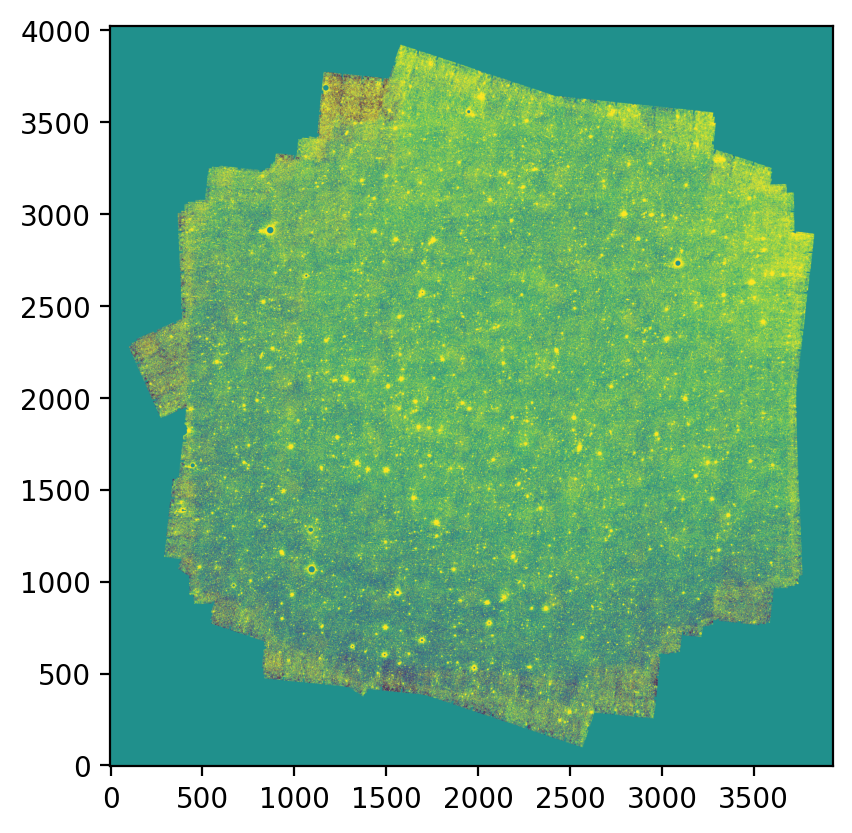

In [11]:
plt.imshow(maps['sc_mean_map']['data'], vmin=-10, vmax=10, origin='lower')

In [39]:
np.max(maps['sc_mean_map']['data'] - maps_nooff['sc_mean_map']['data'])

np.float32(0.001953125)

## Results & Cleanup

In [ ]:
mean_map = maps['mean_map']['data']
valid_map = mean_map > 0
vmin, vmax = np.percentile(mean_map[valid_map], [1, 99])

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
im = ax.imshow(
    np.where(valid_map, mean_map, np.nan),
    vmin=vmin, vmax=vmax, origin='lower', cmap='viridis'
)
ax.set_title('Euclid NISP Y-Band Mosaic')
plt.colorbar(im, ax=ax, label='MJy/sr')
plt.tight_layout()

In [ ]:
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Cache cleaned up.")

if os.path.exists(nvme_reproj_dir):
    shutil.rmtree(nvme_reproj_dir)
    print("NVMe reproj cache cleaned up.")

del cc, mm
gc.collect()